## Entregável 1

In [1]:
import mne
import matplotlib.pyplot as plt

In [2]:
raw = mne.io.read_raw_edf('n1.edf', preload=False)

Extracting EDF parameters from n1.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\1422830383.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('n1.edf', preload=False)
C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\1422830383.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf('n1.edf', preload=False)
C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\1422830383.py:1: RuntimeWarning: Highpass cutoff frequency 10.0 is greater than lowpass cutoff frequency 3.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf('n1.edf', preload=False)


In [3]:
print(f'canais encontrados: {len(raw.ch_names)} => {raw.ch_names}')

canais encontrados: 21 => ['ROC-LOC', 'LOC-ROC', 'F2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'F1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'C4-A1', 'EMG1-EMG2', 'ECG1-ECG2', 'TERMISTORE', 'TORACE', 'ADDOME', 'Dx1-DX2', 'SX1-SX2', 'Posizione', 'HR', 'SpO2']


In [4]:
print(f'Frequência de amostragem (fs): {raw.info['sfreq']} hz')

Frequência de amostragem (fs): 512.0 hz


### Guia de sinais

In [5]:
import pandas as pd

data = {
    "Sinal": ["C4-A1 / F4-C4", "ROC-LOC", "EMG1-EMG2", "ECG1-ECG2", "TERMISTORE", "TORACE / ADDOME", "SpO2"],
    "Tipo": ["EEG (Cérebro)", "EOG (Olhos)", "EMG (Músculo)", "ECG (Coração)", "Fluxo Aéreo", "Esforço Resp.", "Oxímetro"],
    "Por que é importante?": [
        "Identifica estágios de sono e o CAP (ondas Delta, fusos, complexos K).",
        "Essencial para o sono REM (movimentos rápidos dos olhos).",
        "Mostra o relaxamento muscular (atonia no REM) ou bruxismo.",
        "Mede frequência cardíaca e ajuda a identificar despertares.",
        "Verifica se o paciente está respirando pelo nariz/boca.",
        "Mede o movimento do peito e abdômen (detecta apneia).",
        "Nível de oxigênio no sangue (ajuda a validar eventos respiratórios)."
    ],
    "Detalhe Técnico": ["512 Hz / Baixa voltagem", "512 Hz / Capta dipolos oculares", "Alta frequência / Ruído muscular", "Sinal forte / Picos R-R", "Sinal lento", "Sinal muito lento / Sensores de cinta", "Valor percentual constante"]
}

df_sinais = pd.DataFrame(data)
print(df_sinais.to_string(index=False))

          Sinal          Tipo                                                  Por que é importante?                       Detalhe Técnico
  C4-A1 / F4-C4 EEG (Cérebro) Identifica estágios de sono e o CAP (ondas Delta, fusos, complexos K).               512 Hz / Baixa voltagem
        ROC-LOC   EOG (Olhos)              Essencial para o sono REM (movimentos rápidos dos olhos).       512 Hz / Capta dipolos oculares
      EMG1-EMG2 EMG (Músculo)             Mostra o relaxamento muscular (atonia no REM) ou bruxismo.      Alta frequência / Ruído muscular
      ECG1-ECG2 ECG (Coração)            Mede frequência cardíaca e ajuda a identificar despertares.               Sinal forte / Picos R-R
     TERMISTORE   Fluxo Aéreo                Verifica se o paciente está respirando pelo nariz/boca.                           Sinal lento
TORACE / ADDOME Esforço Resp.                  Mede o movimento do peito e abdômen (detecta apneia). Sinal muito lento / Sensores de cinta
           SpO2      Oxímet

### Plots

C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\3360445924.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(order=[raw.ch_names.index(c) for c in canais_selecionados],


Using matplotlib as 2D backend.


C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\3360445924.py:5: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(order=[raw.ch_names.index(c) for c in canais_selecionados],


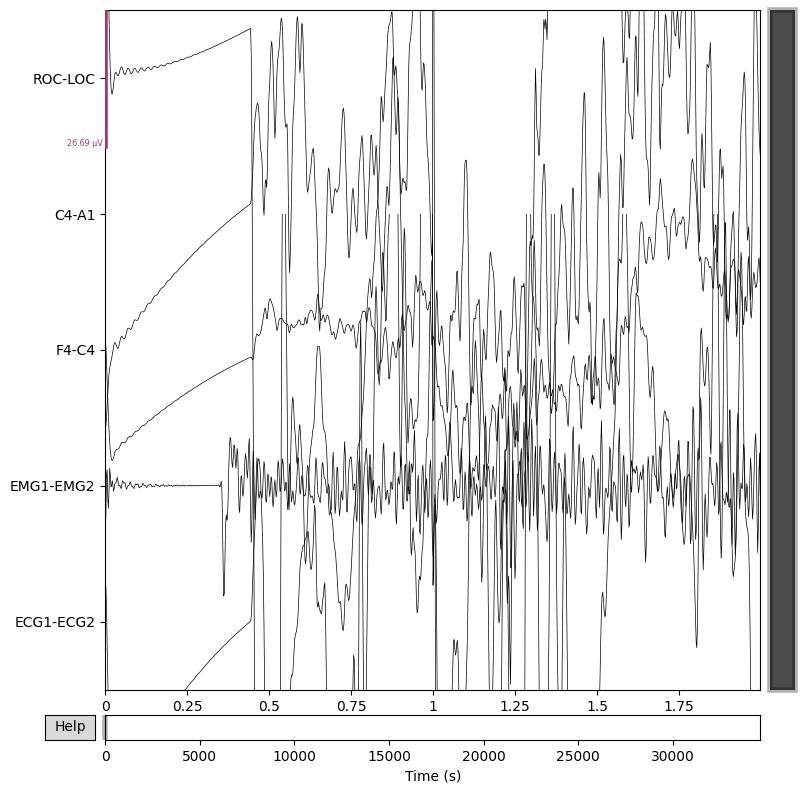

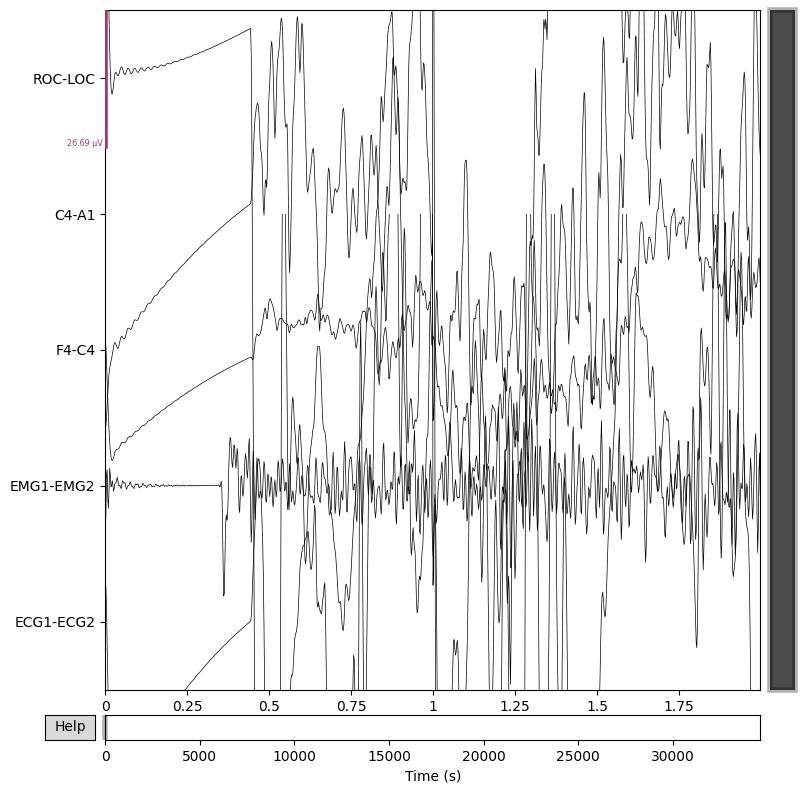

In [6]:
# Escolhendo canais representativos: 1 de olho, 2 de cérebro, 1 de músculo, 1 de coração
canais_selecionados = ['ROC-LOC', 'C4-A1', 'F4-C4', 'EMG1-EMG2', 'ECG1-ECG2']

# Plotando com os canais que escolhi
raw.plot(order=[raw.ch_names.index(c) for c in canais_selecionados], 
         duration=2, 
         title='Sinais Selecionados para Análise de Integridade',
         scalings='auto')

In [7]:
# OBJETIVO: Garantir a integridade física e fisiológica do sinal
# DATASET: CAP Sleep Database (n1.edf / n1.txt)

# 1. TAXA DE AMOSTRAGEM (fs): 
# Identificada como 512 Hz. Justificada pelo Critério de Nyquist: 
# Como as frequências de interesse no sono (EEG) chegam a ~100Hz, 
# a fs deve ser > 200Hz. 512Hz garante que não haja Aliasing.

# 2. PROTOCOLO EXPERIMENTAL: 
# Polissonografia noturna completa (PSG) realizada em ambiente clínico 
# controlado (Ospedale Maggiore di Parma)

# 3. IDENTIFICAÇÕES VISUAIS REALIZADAS:
# - DRIFT (Deriva): Observada nos primeiros 0.5s. Instabilidade na linha 
#   de base (baseline) enquanto o hardware estabiliza.
# - SATURAÇÃO: Identificada visualmente em canais de maior amplitude (EMG/ECG) 
#   onde o sinal "achata" nos limites de voltagem.
# - RUÍDO: Presença de ruído de alta frequência e possível ruído de 
#   linha (50/60 Hz) que exigirá filtragem posterior.

# 4. CANAIS SELECIONADOS:
# Focamos em EEG (C4-A1), EOG (ROC-LOC), EMG e ECG para capturar 
# a microestrutura do sono e validar a qualidade do sinal.

C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\2697041067.py:2: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(start=20,
C:\Users\paulo\AppData\Local\Temp\ipykernel_7972\2697041067.py:2: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(start=20,


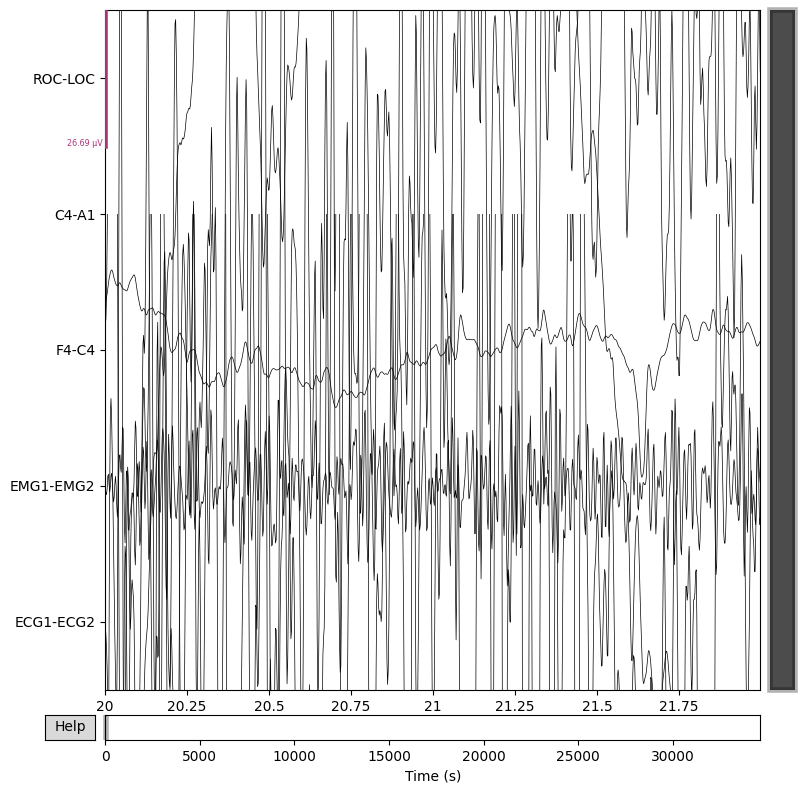

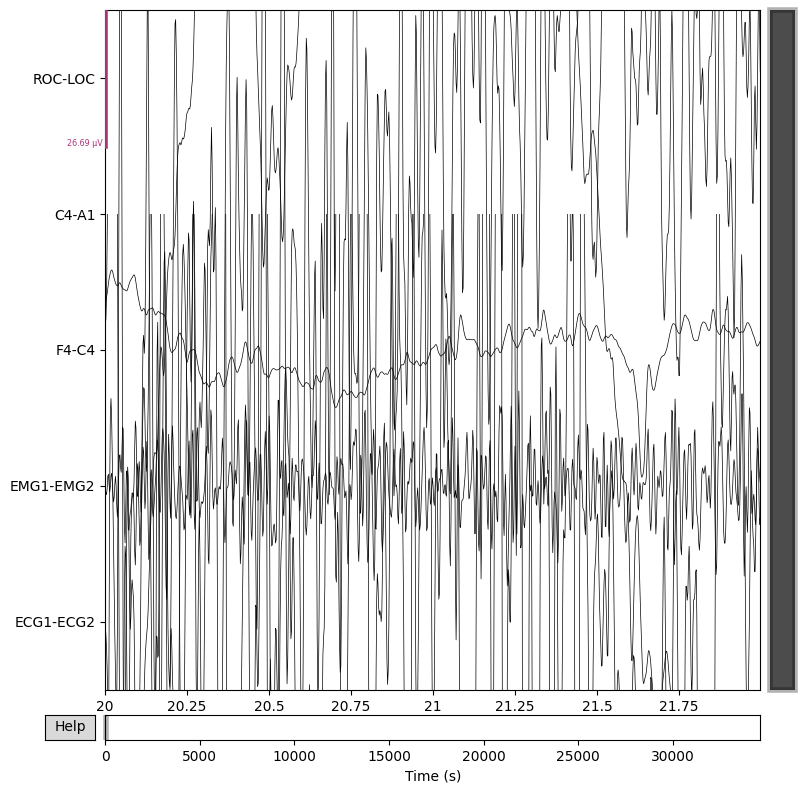

In [8]:
# Plotando um trecho estabilizado (20 a 22 segundos)
raw.plot(start=20, 
         duration=2, 
         order=[raw.ch_names.index(c) for c in canais_selecionados], 
         scalings='auto', 
         title='Sinal Estabilizado (20s-22s)')

In [9]:
import numpy as np 
from scipy.stats import kurtosis, skew
import antropy as ant

In [11]:
def decisor(kurt, snr, se):
    if kurt > 15:
        return "Rejeitar", "Outlier instrumental (Pico/Movimento)"
    
    if snr < 0.1:
        return "Rejeitar", "Sinal pobre (Ruído/Saturação)"
    
    if se > 0.9:
        return "Rejeitar", "Ruído branco (Canal desconectado/Estática)"
    
    return "Aceitar", "Fisiológico"



In [28]:
duracao_janela = 30 #30 segundos
sfreq = raw.info['sfreq']
num_amostras = int(duracao_janela * sfreq)

data, times = raw.get_data(picks='C4-A1', return_times = True)
data = data[0]

for i in range(800, 810):
    inicio = i* num_amostras
    fim = inicio + num_amostras
    janela = data[inicio:fim]

    kurt = kurtosis(janela)
    sk = skew(janela)    
    spec_entropy = ant.spectral_entropy(janela, sf=sfreq, method='welch', normalize=True)
    janela_centralizada = janela - np.mean(janela) #centraliza o sinal pro cálculo de snr
    snr = 10 * np.log10(np.mean(janela_centralizada ** 2)/np.var(janela))
    status, motivo = decisor(kurt, snr, spec_entropy)
    print(f"Janela {i+1} | Kurtosis: {kurt:.2f} | Skewness: {sk:.2f} | Entropia: {spec_entropy:.2f} | SNR: {snr:.2f} dB | {status} - {motivo}")


Janela 801 | Kurtosis: 1.08 | Skewness: 0.29 | Entropia: 0.40 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 802 | Kurtosis: 2.58 | Skewness: 0.01 | Entropia: 0.38 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 803 | Kurtosis: 3.34 | Skewness: -0.03 | Entropia: 0.52 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 804 | Kurtosis: 0.08 | Skewness: -0.05 | Entropia: 0.47 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 805 | Kurtosis: 0.62 | Skewness: 0.20 | Entropia: 0.41 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 806 | Kurtosis: 1.67 | Skewness: 0.06 | Entropia: 0.36 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 807 | Kurtosis: 3.75 | Skewness: 0.20 | Entropia: 0.35 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 808 | Kurtosis: 3.85 | Skewness: -0.16 | Entropia: 0.35 | SNR: 0.00 dB | Rejeitar - Sinal pobre (Ruído/Saturação)
Janela 809 | Kurtosis: 1.50 | Skewnes

In [ ]:
janelas_limpas = []

# Dentro do seu loop...
if status == "Aceitar":
    janelas_limpas.append(janela)

# Transformando em um array final para o modelo
base_estatistica = np.array(janelas_limpas)